In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error,r2_score
import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>


<h2>1) Préparation de données</h2>


In [2]:
np.random.seed(44) #à chaque exécution,générer le même dataset de manière aléatoire
# Coefficients
a1, a2, b = 2, 3, 5  # y = 2*X1 + 3*X2 + 5 + bruit
nombre_points = 100 # Nombre de points
# Génération des deux features (X1 et X2)
X1 = np.random.rand(nombre_points) * 10
X2 = np.random.rand(nombre_points) * 10
# Empilement des features dans une seule matrice (shape: (100, 2))
X = np.column_stack((X1, X2))
# Génération du bruit
bruit = np.random.randn(nombre_points) * 2  # Bruit
# Calcul de la target
y = a1 * X1 + a2 * X2 + b + bruit

#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


Shape of X_train: (80, 2)
Shape of X_test: (20, 2)


<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>


In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


<h2>2) Modèle de réseau de neurones</h2>


In [4]:
# 2-b) Créer le modèle
model_nn = Sequential([Input(shape=(2,))]) # ?
output_layer = Dense(1, activation='linear') # ?
model_nn.add(output_layer)

# 2-c) Compiler le modèle
model_nn.compile(optimizer=Adam(learning_rate=0.1), loss='mse', metrics=['mse']) # ?

# 2-d) Entraîner le modèle
history = model_nn.fit(X_train, y_train, epochs=4000, verbose=0) # ?

# 2-f) Afficher le détail de l'architecture du réseau
model_nn.summary()

# 2-g) Afficher les paramètres
W,bias = output_layer.get_weights()
print("2-g) Paramètres du modèle:")
print("Poids (W1, W2):", W.flatten())
print("Biais:", bias)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

2-g) Paramètres du modèle:
Poids (W1, W2): [1.8767396 3.0535674]
Biais: [5.1477118]


<h2>3) Prédiction en utilisant le modèle</h2>


In [5]:
# 3-a) En utilisant le modèle « model_nn », faire les prédictions en utilisant X_test. Stocker le résultat dans yhat_nn
yhat_nn = model_nn.predict(X_test).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [6]:
yhat_nn=yhat_nn.flatten()

In [7]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# 3-b) En utilisant les paramètres du modèle, faire une prédiction sans utilisation de predict de tensorflow.keras.Sequential
yhat_manual = np.dot(X_test, W_nn) + bias_nn
yhat_manual = yhat_manual.flatten()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)


Poids : [1.8767396 3.0535674]
Biais : [5.1477118]


In [8]:
W,bias

(array([[1.8767396],
        [3.0535674]], dtype=float32),
 array([5.1477118], dtype=float32))

In [9]:
import numpy as np
print("diff keras & manual :", np.max(np.abs(yhat_nn - yhat_manual)))

diff keras & manual : 2.6298515614087137e-06


<h2>4) Evaluation du modèle</h2>


3.82217603623056 0.9660669751507636


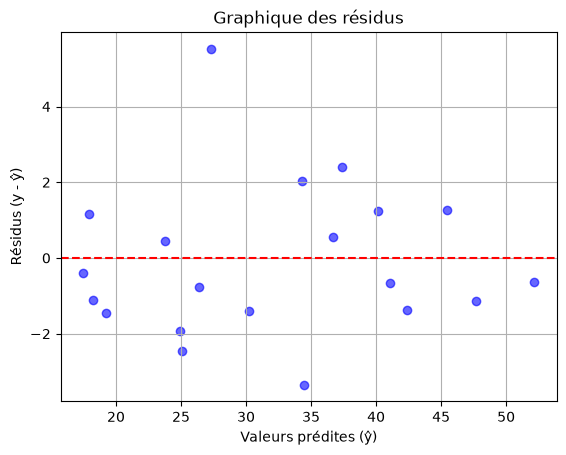

In [10]:
mse_nn = mean_squared_error(y_test, yhat_nn)
r2_nn = r2_score(y_test, yhat_nn)

print(mse_nn,r2_nn)

import matplotlib.pyplot as plt

# Tracé des résidus
plt.scatter(yhat_nn, y_test - yhat_nn, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites (ŷ)")
plt.ylabel("Résidus (y - ŷ)")
plt.title("Graphique des résidus")
plt.grid(True)
plt.show()


In [11]:
# 4-a) Performance du modèle sur training set
yhat_train = model_nn.predict(X_train).flatten()

mse_train = mean_squared_error(y_train, yhat_train)
r2_train = r2_score(y_train, yhat_train)

print("4-a) Performance sur le Training Set:")
print(f"Train MSE : {mse_train}")
print(f"Train R2 : {r2_train}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4-a) Performance sur le Training Set:
Train MSE : 4.017763520886156
Train R2 : 0.9511804514384035


In [12]:
# 4-b) Performance du modèle sur test set
print(f"Test MSE : {mse_nn}")
print(f"Test R2 : {r2_nn}")

Test MSE : 3.82217603623056
Test R2 : 0.9660669751507636


<h1>From scratch</h1>


<h1 style="color: red;"> Section 3 :Régression linéaire from scratch </h1>


<h2>Modèle (version1) de régression linéaire from scratch avec utilisation des matrices</h2>


In [13]:
import numpy as np

# Données du tableau (Exercice 2 - Question 1)
X_toy = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
Y_toy = np.array([[10], [20], [30], [40]])

# Initialisation selon l'énoncé
W_toy = np.array([[0.2], [0.3]])
b_toy = 0.1
n_toy = len(Y_toy)
learning_rate_toy = 0.01 # Arbitraire pour la mise à jour

# a) Calcul de la prédiction
y_pred_toy = X_toy @ W_toy + b_toy
print("a) Prédictions:\n", y_pred_toy)

# b) Calcul des erreurs
error_toy = y_pred_toy - Y_toy
print("\nb) Erreurs:\n", error_toy)

# c) Calcul des gradients
dW_toy = (1/n_toy) * (X_toy.T @ error_toy)
db_toy = (1/n_toy) * np.sum(error_toy)
print("\nc) Gradients dW:\n", dW_toy)
print("c) Gradient db:", db_toy)

# d) Mise à jour du modèle
W_toy_updated = W_toy - learning_rate_toy * dW_toy
b_toy_updated = b_toy - learning_rate_toy * db_toy
print("\nd) Nouveau W:\n", W_toy_updated)
print("d) Nouveau b:", b_toy_updated)

a) Prédictions:
 [[0.9]
 [1.9]
 [2.9]
 [3.9]]

b) Erreurs:
 [[ -9.1]
 [-18.1]
 [-27.1]
 [-36.1]]

c) Gradients dW:
 [[-112.9]
 [-135.5]]
c) Gradient db: -22.6

d) Nouveau W:
 [[1.329]
 [1.655]]
d) Nouveau b: 0.326


In [14]:
# # 2) Compléter le code source de manière à entrainer le modèle
learning_rate = 0.015
epochs = 6000

# Initialisation des paramètres
W = np.zeros((2, 1)) # Shape: (2, 1)
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates
y_train = y_train.reshape(-1, 1)
n = len(X_train)

# Entrainement (descente de gradient vectorisée)
for epoch in range(epochs):
    # Multiplication matricielle (@) avec les poids W, plus le biais b
    y_pred = X_train @ W + b
    
    error = y_pred - y_train
    
    # Calcul des gradients
    dW = (1 / n) * (X_train.T @ error)
    db = (1 / n) * np.sum(error)
    
    # Mise à jour des paramètres
    W -= learning_rate * dW
    b -= learning_rate * db

# Résultats
print("Paramètres ajustés:")
print(f"W =\n{W}")
print(f"b = {b:.4f}")

Paramètres ajustés:
W =
[[1.94894806]
 [3.00147433]]
b = 5.2245


In [15]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# --- 3) Évaluer le modèle custom sur le test set ---
# Reshape de y_test pour éviter les conflits de dimension
y_test_reshaped = y_test.reshape(-1, 1)

# Prédiction avec notre modèle entrainé
y_pred_custom = X_test @ W + b

print("3) Évaluation du modèle from scratch:")
print("MSE:", mean_squared_error(y_test_reshaped, y_pred_custom))
print("R2 :", r2_score(y_test_reshaped, y_pred_custom))
print("-" * 40)

# --- 4) Comparer les résultats avec sklearn ---
# Entrainement du modèle sklearn
sk_model = LinearRegression()
sk_model.fit(X_train, y_train) # On utilise le dataset d'entraînement

# Prédiction
sk_pred = sk_model.predict(X_test)

print("4) Comparaison avec Sklearn:")
print(f"Sklearn W : \n{sk_model.coef_.T}")
print(f"Sklearn b : {sk_model.intercept_[0]:.4f}")
print("Sklearn MSE:", mean_squared_error(y_test_reshaped, sk_pred))
print("Sklearn R2 :", r2_score(y_test_reshaped, sk_pred))

3) Évaluation du modèle from scratch:
MSE: 3.559894865754471
R2 : 0.9683954899525122
----------------------------------------
4) Comparaison avec Sklearn:
Sklearn W : 
[[1.94893637]
 [3.00146063]]
Sklearn b : 5.2247
Sklearn MSE: 3.5599097039193417
Sklearn R2 : 0.9683953582202706
